Task 1: Preprocess and Explore the Data

Imports and setup

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

Extract historical data from YFinance

In [3]:
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

raw_data = {}
for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)
    if df is None or df.empty:
        raise ValueError(f"No data returned for {ticker}")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    raw_data[ticker] = df
    print(ticker, df.shape)

TSLA (2888, 6)
BND (2888, 6)
SPY (2888, 6)


Basic stats and dtypes check

In [4]:
for ticker, df in raw_data.items():
    print(f"--- {ticker} ---")
    print(df.dtypes)
    print(df.describe())
    print("Missing values:\n", df.isna().sum())
    print()

--- TSLA ---
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object
         Adj Close        Close         High          Low         Open  \
count  2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean    148.773923   148.773923   151.990563   145.416731   148.797341   
std     138.895957   138.895957   141.852818   135.867193   138.977191   
min       9.578000     9.578000    10.331333     9.403333     9.488000   
25%      18.393499    18.393499    18.665168    18.023666    18.390833   
50%     133.437668   133.437668   136.053329   125.831669   131.496330   
75%     251.925831   251.925831   257.485008   245.832500   251.680004   
max     489.880005   489.880005   498.829987   485.329987   489.880005   

             Volume  
count  2.888000e+03  
mean   1.087922e+08  
std    7.082549e+07  
min    1.062000e+07  
25%    6.548325e+07  
50%    9.033615e+07  
75%    1.261204e+08  
max 

Combine closing prices and clean

In [5]:
adj_close = pd.DataFrame({t: raw_data[t]['Adj Close'] for t in tickers})

# Reindex onto a full business-day calendar, then forward-fill non-trading days
full_index = pd.bdate_range(adj_close.index.min(), adj_close.index.max())
adj_close = adj_close.reindex(full_index)
adj_close.index.name = 'Date'

missing_before = adj_close.isna().sum()
adj_close = adj_close.ffill().bfill()
missing_after = adj_close.isna().sum()

print("Missing before:\n", missing_before)
print("Missing after:\n", missing_after)

adj_close.to_csv('adj_close_combined.csv')

Missing before:
 TSLA    109
BND     109
SPY     109
dtype: int64
Missing after:
 TSLA    0
BND     0
SPY     0
dtype: int64


Why forward-fill and not drop/interpolate? For price series, forward-filling (carrying the last traded price forward on holidays) is standard — it reflects reality (no trading happened) better than linear interpolation, which would fabricate price movement that didn't occur.

EDA: closing price over time

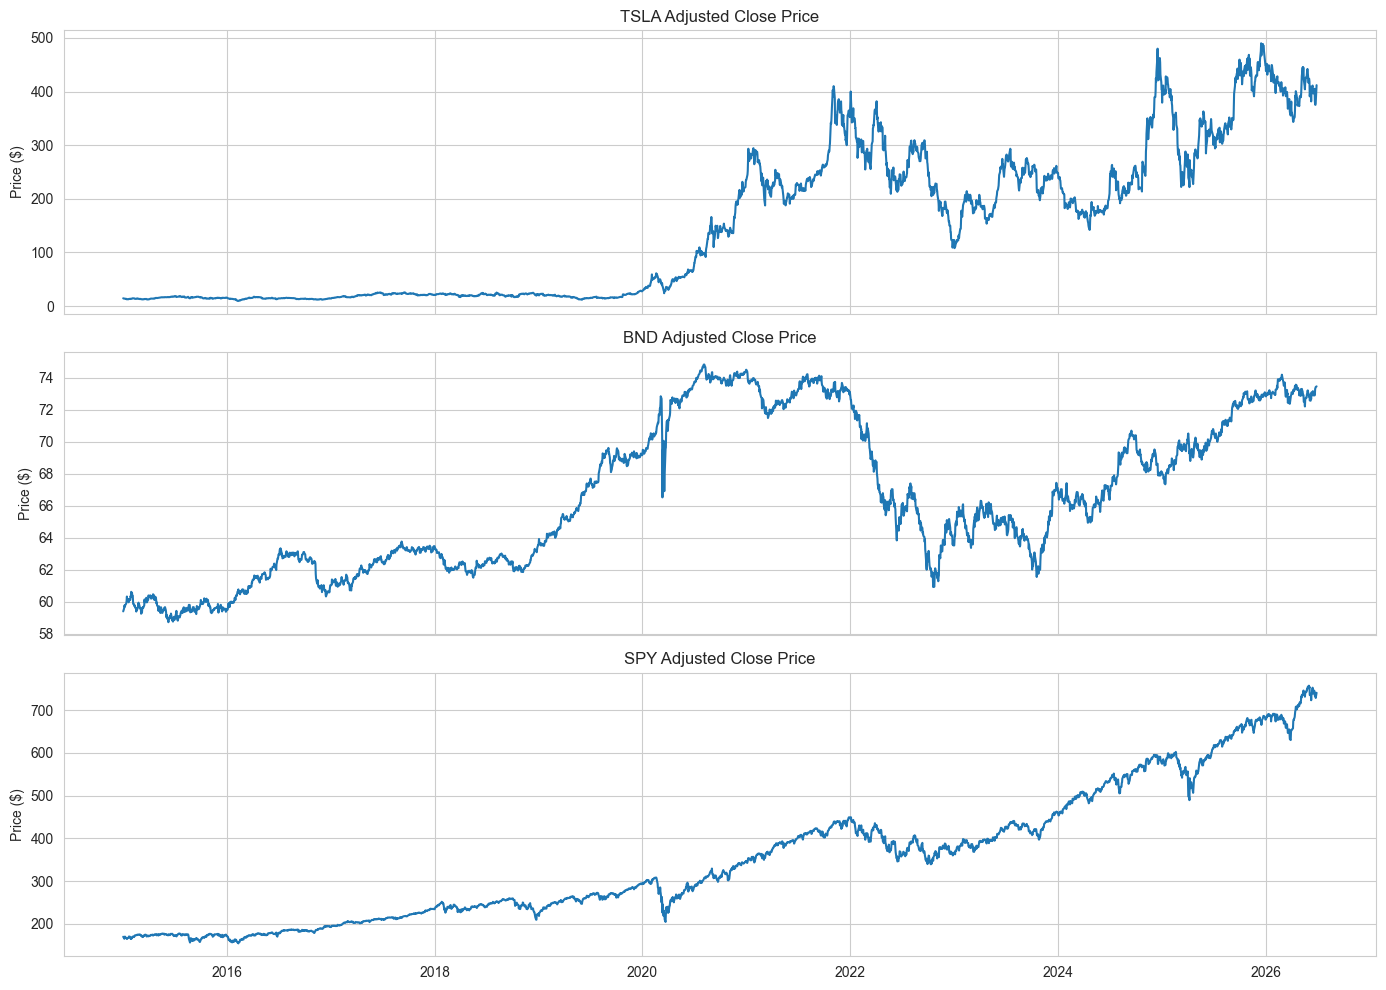

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, adj_close.columns):
    ax.plot(adj_close.index, adj_close[col])
    ax.set_title(f'{col} Adjusted Close Price')
    ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

Daily returns (volatility)

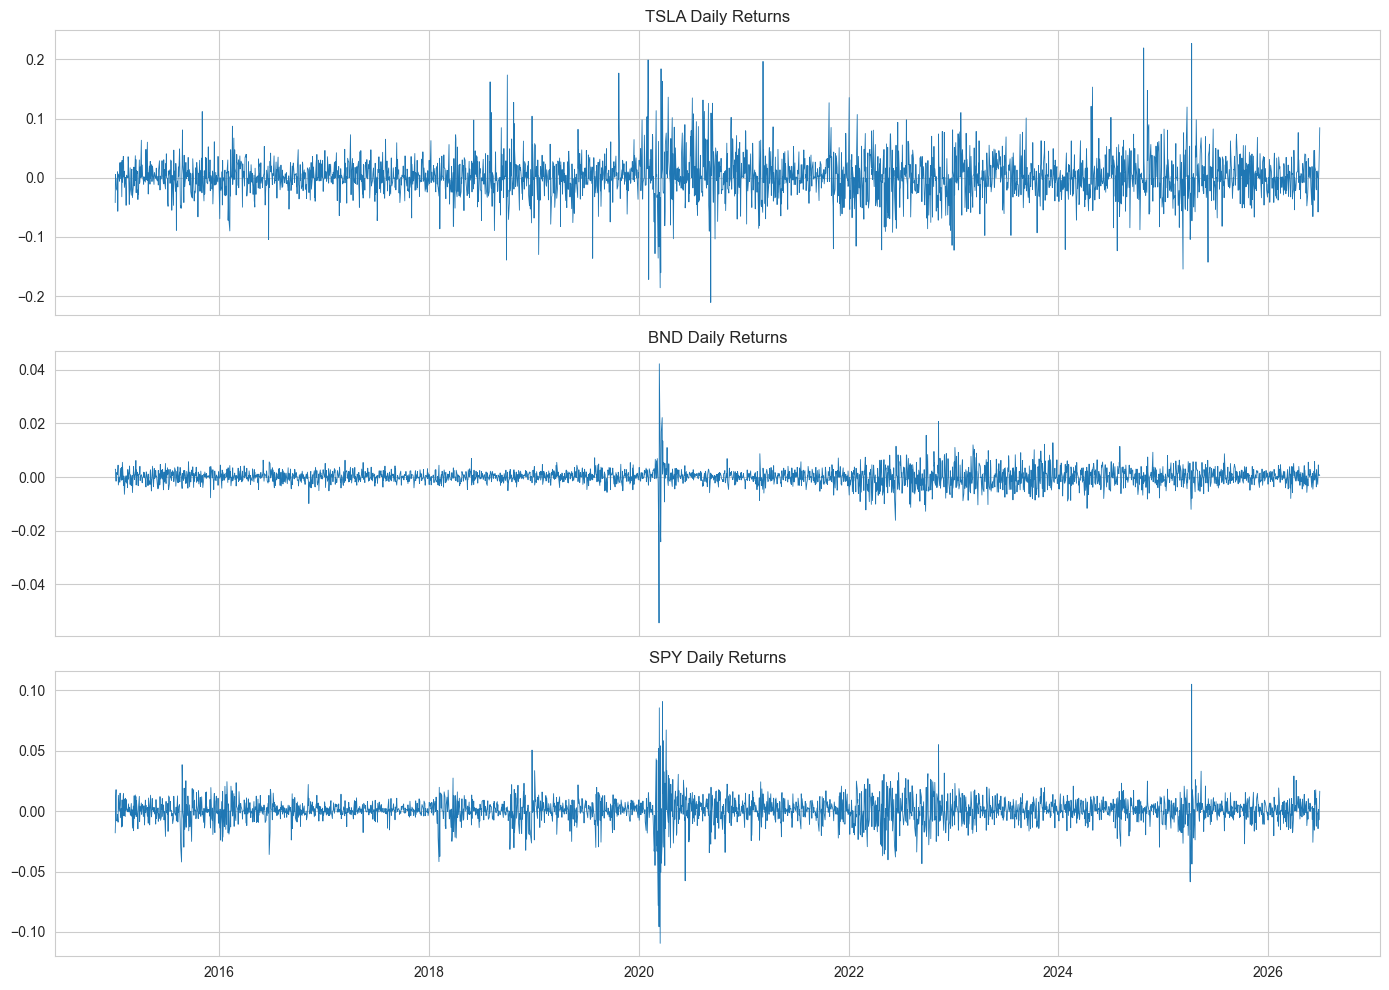

In [7]:
returns = adj_close.pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col], linewidth=0.6)
    ax.set_title(f'{col} Daily Returns')
plt.tight_layout()
plt.show()

Rolling mean/std (short-term trend & volatility clustering)

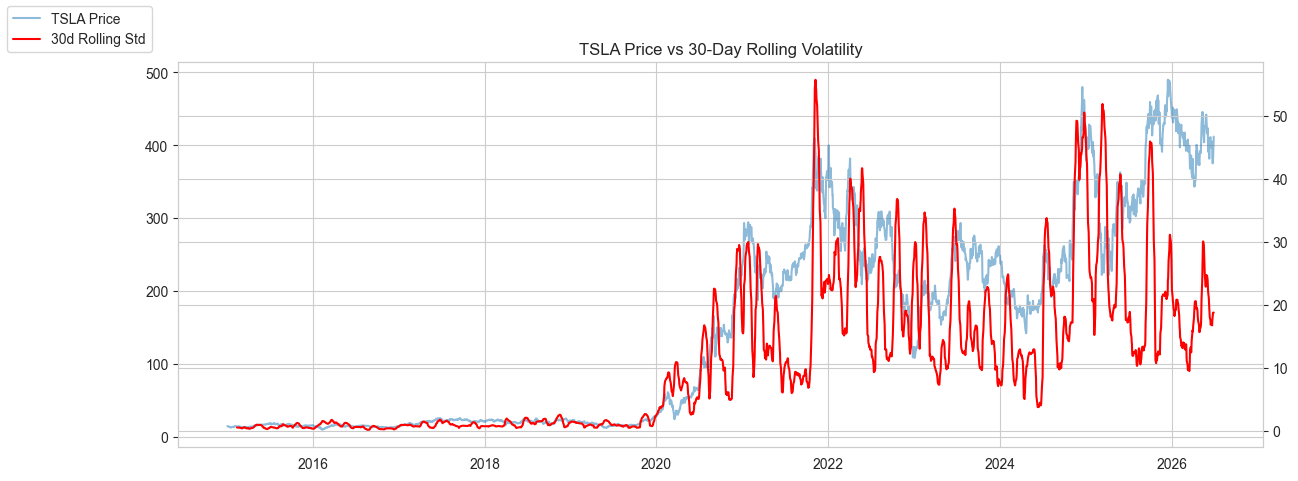

In [8]:
window = 30
tsla_roll_mean = adj_close['TSLA'].rolling(window).mean()
tsla_roll_std = adj_close['TSLA'].rolling(window).std()

fig, ax = plt.subplots()
ax.plot(adj_close.index, adj_close['TSLA'], label='TSLA Price', alpha=0.5)
ax2 = ax.twinx()
ax2.plot(tsla_roll_std.index, tsla_roll_std, color='red', label='30d Rolling Std')
ax.set_title('TSLA Price vs 30-Day Rolling Volatility')
fig.legend(loc='upper left')
plt.show()

Outlier detection

In [9]:
def detect_outliers(returns_series, n_std=3.0):
    mean, std = returns_series.mean(), returns_series.std()
    mask = (returns_series - mean).abs() > n_std * std
    return returns_series[mask].sort_values()

for col in returns.columns:
    outliers = detect_outliers(returns[col])
    print(f"{col}: {len(outliers)} days beyond 3 std")
    print(outliers)
    print()

TSLA: 50 days beyond 3 std
Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
2020-03-18   -0.160344
2025-03-10   -0.154262
2025-06-05   -0.142599
2018-09-28   -0.139015
2019-07-25   -0.136137
2020-03-09   -0.135725
2019-01-18   -0.129711
2020-02-27   -0.128146
2024-07-24   -0.123346
2023-01-03   -0.122422
2022-04-26   -0.121841
2024-01-25   -0.121253
2021-11-09   -0.119903
2020-03-12   -0.116172
2022-01-27   -0.115542
2022-12-27   -0.114089
2016-06-22   -0.104503
2020-07-10    0.107848
2020-09-09    0.109233
2023-01-26    0.109673
2018-08-07    0.109886
2023-01-27    0.110002
2015-11-04    0.111735
2020-08-17    0.112031
2020-03-02    0.113220
2025-03-24    0.119336
2024-04-24    0.120611
2020-08-31    0.125689
2020-09-14    0.125832
2021-10-25    0.126616
2018-10-23    0.127189
2020-08-12    0.131236
2020-07-06    0.134794
2022-01-03    0.135317
2020-04-13    0.136038
2020-02-04    0.137256
2024-11-06    0.147510
2024-04-29    0.153069
2018-08-02    0.161880
20

Stationarity: Augmented Dickey-Fuller test

In [10]:
def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary at 5%? {'Yes' if result[1] < 0.05 else 'No'}")
    print()
    return result

adf_test(adj_close['TSLA'], 'TSLA Close Price')
adf_test(returns['TSLA'], 'TSLA Daily Returns')

ADF Test: TSLA Close Price
  ADF Statistic: -1.0387
  p-value: 0.7389
  Stationary at 5%? No

ADF Test: TSLA Daily Returns
  ADF Statistic: -55.1498
  p-value: 0.0000
  Stationary at 5%? Yes



(np.float64(-55.149764326202316),
 0.0,
 0,
 2995,
 {'1%': np.float64(-3.432535279976574),
  '5%': np.float64(-2.8625055152431513),
  '10%': np.float64(-2.5672839692475775)},
 np.float64(-11388.670896008844))

raw price levels will almost certainly fail to reject the null (p > 0.05 → non-stationary — prices are a random walk, consistent with the Efficient Market Hypothesis). Daily returns should reject the null (p < 0.05 → stationary). This is exactly why ARIMA needs d=1 (first differencing) on price data.

Risk metrics: VaR and Sharpe Ratio

In [11]:
def value_at_risk(returns_series, confidence=0.95):
    return np.percentile(returns_series.dropna(), (1 - confidence) * 100)

def sharpe_ratio(returns_series, risk_free_rate=0.02, periods_per_year=252):
    excess = returns_series - risk_free_rate / periods_per_year
    return np.sqrt(periods_per_year) * excess.mean() / excess.std()

summary = pd.DataFrame({
    'annualized_return': returns.mean() * 252,
    'annualized_volatility': returns.std() * np.sqrt(252),
    'VaR_95_daily': returns.apply(value_at_risk),
    'sharpe_ratio': returns.apply(sharpe_ratio),
})
print(summary)

      annualized_return  annualized_volatility  VaR_95_daily  sharpe_ratio
TSLA           0.437713               0.561299     -0.051096      0.744189
BND            0.019231               0.052160     -0.004724     -0.014744
SPY            0.139070               0.173313     -0.016354      0.687022
